In [1]:
!pip uninstall -y numpy torch torchvision torchaudio opencv-python opencv-python-headless shap jax jaxlib hdbscan umap-learn imbalanced-learn rasterio tobler pytensor xarray-einstats -q

In [2]:
!pip install --upgrade --force-reinstall numpy==1.26.4
!pip install --upgrade --force-reinstall pandas==2.2.2


   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   - -------------------------------------- 0.5/15.5 MB 2.8 MB/s eta 0:00:06
   --- ------------------------------------ 1.3/15.5 MB 2.8 MB/s eta 0:00:06
   ---- ----------------------------------- 1.8/15.5 MB 2.7 MB/s eta 0:00:06
   ------ --------------------------------- 2.6/15.5 MB 2.8 MB/s eta 0:00:05
   ------ --------------------------------- 2.6/15.5 MB 2.8 MB/s eta 0:00:05
   ------ --------------------------------- 2.6/15.5 MB 2.8 MB/s eta 0:00:05
   ------- -------------------------------- 2.9/15.5 MB 2.0 MB/s eta 0:00:07
   -------- ------------------------------- 3.1/15.5 MB 1.8 MB/s eta 0:00:07
   -------- ------------------------------- 3.4/15.5 MB 1.8 MB/s eta 0:00:07
   ---------- ----------------------------- 3.9/15.5 MB 1.8 MB/s eta 0:00:07
   ---------- ----------------------------- 4.2/15.5 MB 1.7 MB/s eta 0:00:07
   ----------

In [4]:
! pip install requests


  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.2.25-py3-none-any.whl.metadata (2.5 kB)
Using cached requests-2.33.1-py3-none-any.whl (64 kB)
Using cached idna-3.11-py3-none-any.whl (71 kB)
Using cached urllib3-2.6.3-py3-none-any.whl (131 kB)
Using cached certifi-2026.2.25-py3-none-any.whl (153 kB)

   ---------------------------------------- 0/5 [urllib3]
   ---------------------------------------- 0/5 [urllib3]
   ---------------------------------------- 0/5 [urllib3]
   ---------------------------------------- 0/5 [urllib3]
   ---------------------------------------- 0/5 [urllib3]
   -------- ------------------------------- 1/5 [idna]
   -------- ------------------------------- 1/5 [idna]
   ---------------- ----------------------- 2/5 [charset_normalizer]
   ------------------------ --------------- 3/5 [certifi]
  

In [6]:
! pip install polars


   ---------------------------------------- 0.0/824.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/824.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/824.0 kB ? eta -:--:--
   ------------------------- -------------- 524.3/824.0 kB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 824.0/824.0 kB 2.8 MB/s  0:00:00
   ---------------------------------------- 0.0/47.0 MB ? eta -:--:--
    --------------------------------------- 0.8/47.0 MB 4.8 MB/s eta 0:00:10
   - -------------------------------------- 1.6/47.0 MB 3.8 MB/s eta 0:00:12
   - -------------------------------------- 2.1/47.0 MB 3.6 MB/s eta 0:00:13
   -- ------------------------------------- 2.6/47.0 MB 3.6 MB/s eta 0:00:13
   -- ------------------------------------- 3.1/47.0 MB 2.9 MB/s eta 0:00:15
   -- ------------------------------------- 3.1/47.0 MB 2.9 MB/s eta 0:00:15
   -- ------------------------------------- 3.4/47.0 MB 2.6 MB/s eta 0:00:17
   --- --------------

In [7]:
! pip install mlflow "pydantic<2.0" "fastapi<0.100" scikit-learn pandas numpy requests polars


  Using cached mlflow-3.11.1-py3-none-any.whl.metadata (49 kB)
  Using cached fastapi-0.99.1-py3-none-any.whl.metadata (23 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached starlette-0.27.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached mlflow_skinny-3.11.1-py3-none-any.whl.metadata (49 kB)
  Using cached mlflow_tracing-3.11.1-py3-none-any.whl.metadata (19 kB)
  Using cached flask-3.1.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached alembic-1.18.4-py3-none-any.whl.metadata (7.2 kB)
  Using cached cryptography-46.0.7-cp311-abi3-win_amd64.whl.metadata (5.7 kB)
  Using cached docker-7.1.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached graphene-3.4.3-py2.py3-none-any.whl.metadata (6.9 kB)
  Using cached huey-2.6.0-py3-none-any.whl.metadata (4.3 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-win_amd

## Assignment 2 Repeat

In [8]:
# Data Ingestion & Cleaning

import os
import requests
from urllib.parse import urlparse
import polars as pl
import pandas as pd

os.makedirs('data/raw', exist_ok=True)
files_to_download = {
    "Yellow Taxi Trip Data": "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet",
    "Taxi Zone Lookup Table": "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
}

for file_name_base, url in files_to_download.items():
    response = requests.get(url)
    parsed_url = urlparse(url)
    original_extension = os.path.splitext(parsed_url.path)[1]
    local_file_name = f'data/raw/{file_name_base}{original_extension}'

    with open(local_file_name, 'wb') as f:
        f.write(response.content)
    print(f"{file_name_base} downloaded successfully to {local_file_name}.")


taxi_file = 'data/raw/Yellow Taxi Trip Data.parquet'
df = pl.read_parquet(taxi_file)
print(f'Yellow taxi data starts with {len(df):,} rows')

# Drop rows with nulls in critical columns
critical_cols = ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'PULocationID', 'DOLocationID', 'fare_amount', 'tip_amount', 'payment_type']
before = len(df)
df = df.drop_nulls(subset=critical_cols)
after = len(df)
print(f'{after:,} rows remain after removing {before - after:,} null rows')

# Remove trips with invalid distance or fare
before = len(df)
df = df.filter((pl.col('trip_distance') > 0) &
               (pl.col('fare_amount') > 0) &
               (pl.col('fare_amount') <= 500))
after = len(df)
print(f'{after:,} rows remain after removing {before - after:,} invalid trips')

# Remove rows where dropoff is before pickup
before = len(df)
df = df.filter(pl.col('tpep_dropoff_datetime') >= pl.col('tpep_pickup_datetime'))
after = len(df)
print(f'{after:,} rows remain after removing {before - after:,} dropoff errors')

# Filter for credit card payments only
before = len(df)
df = df.filter(pl.col('payment_type') == 1)
after = len(df)
print(f'{after:,} rows remain after filtering for credit card payments (removed {before - after:,})')

rows_removed = len(pl.read_parquet(taxi_file)) - len(df)
print(f'{rows_removed:,} rows removed overall')


df = df.to_pandas()

zones = pd.read_csv('data/raw/Taxi Zone Lookup Table.csv')
df = df.merge(zones[['LocationID', 'Borough']], left_on='PULocationID', right_on='LocationID', how='left')

df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

print("Data ready for Part 1: Feature Engineering")
print(f"Final dataset shape: {df.shape}")


Yellow Taxi Trip Data downloaded successfully to data/raw/Yellow Taxi Trip Data.parquet.
Taxi Zone Lookup Table downloaded successfully to data/raw/Taxi Zone Lookup Table.csv.
Yellow taxi data starts with 2,964,624 rows
2,964,624 rows remain after removing 0 null rows
2,869,684 rows remain after removing 94,940 invalid trips
2,869,628 rows remain after removing 56 dropoff errors
2,298,380 rows remain after filtering for credit card payments (removed 571,248)
666,244 rows removed overall
Data ready for Part 1: Feature Engineering
Final dataset shape: (2298380, 21)


In [9]:
# Part 1.1: Feature Engineering
import numpy as np

# Temporal features
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day_of_week'] = df['tpep_pickup_datetime'].dt.dayofweek  # 0=Monday
df['is_weekend'] = df['pickup_day_of_week'].isin([5, 6]).astype(int)

# Trip features
df['trip_duration_minutes'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
df['trip_speed_mph'] = df['trip_distance'] / (df['trip_duration_minutes'] / 60).replace(0, np.nan)
df['log_trip_distance'] = np.log1p(df['trip_distance'])

# Fare features
df['fare_per_mile'] = df['fare_amount'] / df['trip_distance'].replace(0, np.nan)
df['fare_per_minute'] = df['fare_amount'] / df['trip_duration_minutes'].replace(0, np.nan)

# Zone features
zones = pd.read_csv('data/raw/Taxi Zone Lookup Table.csv')
borough_map = zones.set_index('LocationID')['Borough'].to_dict()

df['pickup_borough'] = df['PULocationID'].map(borough_map)
df['dropoff_borough'] = df['DOLocationID'].map(borough_map)

df = pd.get_dummies(df, columns=['pickup_borough', 'dropoff_borough'], prefix=['PU', 'DO'])

print("Feature engineering complete")
print("Feature columns created:", [col for col in df.columns if col not in ['tpep_pickup_datetime','tpep_dropoff_datetime']][:15], "...")


Feature engineering complete
Feature columns created: ['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount'] ...


In [10]:
# Target variable for regression
df['tip_amount'] = df['tip_amount']

print("Target variable created")
print("Tip amount sample:", df['tip_amount'].head())


Target variable created
Tip amount sample: 0    3.75
1    3.00
2    2.00
3    3.20
4    6.90
Name: tip_amount, dtype: float64


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

numeric_features = [
    'pickup_hour', 'pickup_day_of_week', 'trip_duration_minutes',
    'trip_speed_mph', 'log_trip_distance', 'fare_per_mile', 'fare_per_minute']

X = df[numeric_features + [col for col in df.columns if col.startswith('PU_') or col.startswith('DO_')]]
y_regression = df['tip_amount']

# Split into train/val/test (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_regression, test_size=0.30, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42)

# Drop rows with NaNs
def drop_nan_rows(X, y):
    mask = ~X.isna().any(axis=1)
    return X[mask], y[mask]

X_train, y_train = drop_nan_rows(X_train, y_train)
X_val, y_val = drop_nan_rows(X_val, y_val)
X_test, y_test = drop_nan_rows(X_test, y_test)

# Scale numeric features
scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_val[numeric_features] = scaler.transform(X_val[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

print("Data splitting and scaling complete")
print(f"Training set: {X_train.shape}, Validation set: {X_val.shape}, Test set: {X_test.shape}")


Data splitting and scaling complete
Training set: (1608841, 21), Validation set: (344753, 21), Test set: (344753, 21)


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

sample_size = 200000
X_train_use = X_train.sample(sample_size, random_state=42)
y_train_use = y_train.loc[X_train_use.index]
print(f"Using {sample_size} rows for baseline regression training")

# Baseline regression models
lin_reg = LinearRegression().fit(X_train_use, y_train_use)
rf_reg = RandomForestRegressor(n_estimators=10, random_state=42, n_jobs=-1).fit(X_train_use, y_train_use)

# Evaluate regression models
for name, model in [('Linear Regression', lin_reg), ('Random Forest Regressor', rf_reg)]:
    y_pred = model.predict(X_val)
    print(f"\n{name} Validation Performance:")
    print("MAE:", mean_absolute_error(y_val, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_val, y_pred)))
    print("R²:", r2_score(y_val, y_pred))


Using 200000 rows for baseline regression training

Linear Regression Validation Performance:
MAE: 1.4229106632196984
RMSE: 2.6040039071441763
R²: 0.5364946297601825

Random Forest Regressor Validation Performance:
MAE: 1.3446240542331687
RMSE: 2.557234720362781
R²: 0.5529946799287013


In [13]:
from sklearn.model_selection import GridSearchCV

sample_size = 200000
X_train_tune = X_train.sample(sample_size, random_state=42)
y_train_tune = y_train.loc[X_train_tune.index]
print(f"Using {sample_size} rows for regression tuning")

# Regression tuning
param_grid_reg = {
    'n_estimators': [10, 20],
    'max_depth': [None, 5],
    'min_samples_split': [2, 5]
}
grid_reg = GridSearchCV(RandomForestRegressor(random_state=42),
                        param_grid_reg, cv=2, n_jobs=-1)
grid_reg.fit(X_train_tune, y_train_tune)
print("Best RF Regressor params:", grid_reg.best_params_)


Using 200000 rows for regression tuning
Best RF Regressor params: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 10}



Regression Models - Test Set Comparison:
                     Model       MAE      RMSE        R²
0        Linear Regression  1.428079  2.698751  0.523257
1  Random Forest Regressor  1.349994  2.643988  0.542409
2       Tuned RF Regressor  1.280121  2.544790  0.576101


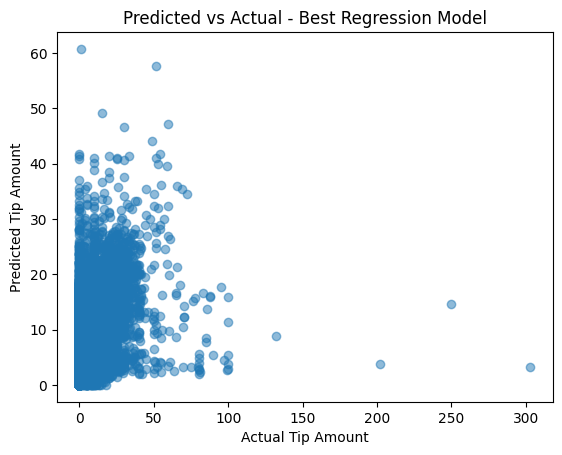

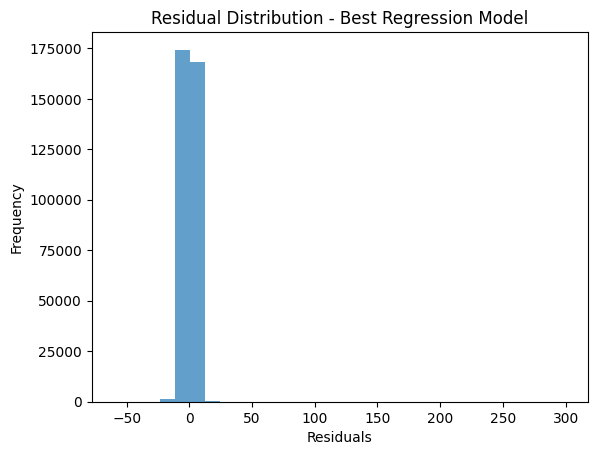

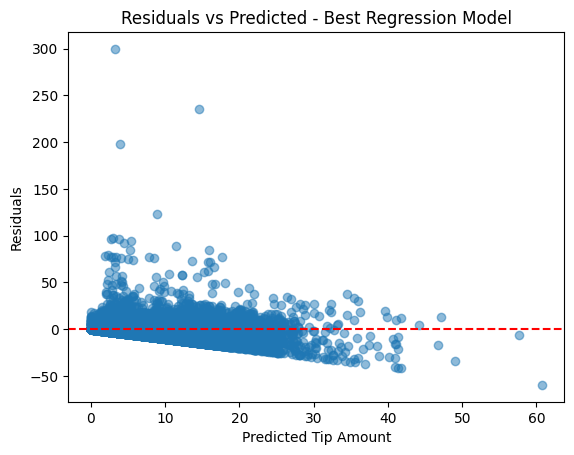

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Evaluate regression models on test set
regression_results_test = {
    "Model": ["Linear Regression", "Random Forest Regressor", "Tuned RF Regressor"],
    "MAE": [
        mean_absolute_error(y_test, lin_reg.predict(X_test)),
        mean_absolute_error(y_test, rf_reg.predict(X_test)),
        mean_absolute_error(y_test, grid_reg.best_estimator_.predict(X_test)) if 'grid_reg' in globals() else None],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lin_reg.predict(X_test))),
        np.sqrt(mean_squared_error(y_test, rf_reg.predict(X_test))),
        np.sqrt(mean_squared_error(y_test, grid_reg.best_estimator_.predict(X_test))) if 'grid_reg' in globals() else None],
    "R²": [
        r2_score(y_test, lin_reg.predict(X_test)),
        r2_score(y_test, rf_reg.predict(X_test)),
        r2_score(y_test, grid_reg.best_estimator_.predict(X_test)) if 'grid_reg' in globals() else None]
}
regression_df_test = pd.DataFrame(regression_results_test)
print("\nRegression Models - Test Set Comparison:")
print(regression_df_test)

# Scatter plot for best regression model (example: RF Regressor)
best_reg = rf_reg
y_pred_best = best_reg.predict(X_test)
plt.scatter(y_test, y_pred_best, alpha=0.5)
plt.xlabel("Actual Tip Amount")
plt.ylabel("Predicted Tip Amount")
plt.title("Predicted vs Actual - Best Regression Model")
plt.show()

# Residual analysis
residuals = y_test - y_pred_best
plt.hist(residuals, bins=30, alpha=0.7)
plt.title("Residual Distribution - Best Regression Model")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

plt.scatter(y_pred_best, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Tip Amount")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted - Best Regression Model")
plt.show()


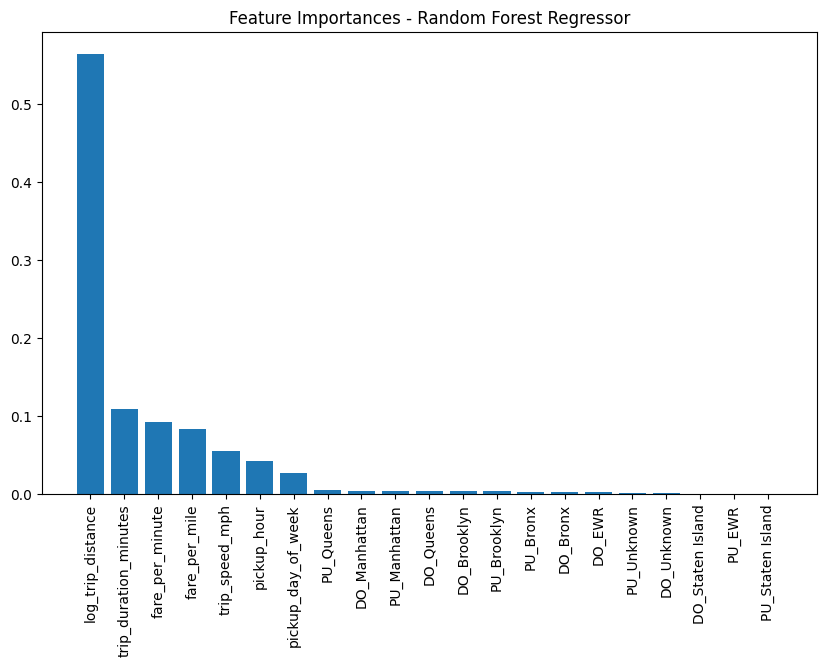


Linear Regression Coefficients:
                  Feature   Coefficient
16                 DO_EWR  3.685418e+00
4       log_trip_distance  2.221337e+00
19       DO_Staten Island  1.775543e+00
6         fare_per_minute  2.150540e-01
0             pickup_hour  8.665722e-02
5           fare_per_mile  8.496355e-02
2   trip_duration_minutes  1.758527e-02
12       PU_Staten Island -1.065814e-14
1      pickup_day_of_week -6.270749e-02
3          trip_speed_mph -8.247578e-02
11              PU_Queens -1.132948e+00
10           PU_Manhattan -3.454846e+00
13             PU_Unknown -3.571077e+00
18              DO_Queens -3.653176e+00
20             DO_Unknown -4.006924e+00
17           DO_Manhattan -4.193269e+00
15            DO_Brooklyn -4.515838e+00
14               DO_Bronx -6.092068e+00
8             PU_Brooklyn -7.435896e+00
7                PU_Bronx -9.488597e+00
9                  PU_EWR -9.752862e+00


In [15]:
# Random Forest feature importance
importances = rf_reg.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10,6))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), X_train.columns[indices], rotation=90)
plt.title("Feature Importances - Random Forest Regressor")
plt.show()

# Linear Regression coefficients
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lin_reg.coef_
}).sort_values(by="Coefficient", ascending=False)
print("\nLinear Regression Coefficients:")
print(coef_df)


## Part 1

### Part 1.1

In [16]:
#Step 1
import mlflow
import mlflow.sklearn

# Start local tracking (default is ./mlruns folder)
mlflow.set_tracking_uri("file:./mlruns")

# Create or set experiment
mlflow.set_experiment("taxi-tip-prediction")

2026/04/14 03:35:48 INFO mlflow.tracking.fluent: Experiment with name 'taxi-tip-prediction' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:c:/Users/shani/Downloads/COMP3610_Assignment-4/mlruns/877646091967902175', creation_time=1776152149003, experiment_id='877646091967902175', last_update_time=1776152149003, lifecycle_stage='active', name='taxi-tip-prediction', tags={}>

In [17]:
# Step 2
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

with mlflow.start_run(run_name="RandomForestRegressor"):
    # Train model
    rf_reg = RandomForestRegressor(
        n_estimators=20,
        max_depth=5,
        min_samples_split=2,
        random_state=42,
        n_jobs=-1
    )
    rf_reg.fit(X_train, y_train)

    # Evaluate
    y_pred = rf_reg.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Log parameters, metrics, model, tags
    mlflow.log_params({
        "n_estimators": 20,
        "max_depth": 5,
        "min_samples_split": 2
    })
    mlflow.log_metrics({"MAE": mae, "RMSE": rmse, "R2": r2})
    mlflow.sklearn.log_model(rf_reg, "model")
    mlflow.set_tags({"model_type": "RandomForestRegressor", "dataset_version": "2024-01"})

print("Random Forest run logged to MLflow")


2026/04/14 03:36:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/14 03:36:35 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Random Forest run logged to MLflow


In [18]:
#Step 3
from sklearn.linear_model import LinearRegression

with mlflow.start_run(run_name="LinearRegression"):
    # Train model
    lin_reg = LinearRegression()
    lin_reg.fit(X_train, y_train)

    # Evaluate
    y_pred = lin_reg.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Log parameters, metrics, model, tags
    mlflow.log_params({"fit_intercept": lin_reg.fit_intercept})
    mlflow.log_metrics({"MAE": mae, "RMSE": rmse, "R2": r2})
    mlflow.sklearn.log_model(lin_reg, "model")
    mlflow.set_tags({"model_type": "LinearRegression", "dataset_version": "2024-01"})

print("Linear Regression run logged to MLflow")


2026/04/14 03:36:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/14 03:36:46 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Linear Regression run logged to MLflow


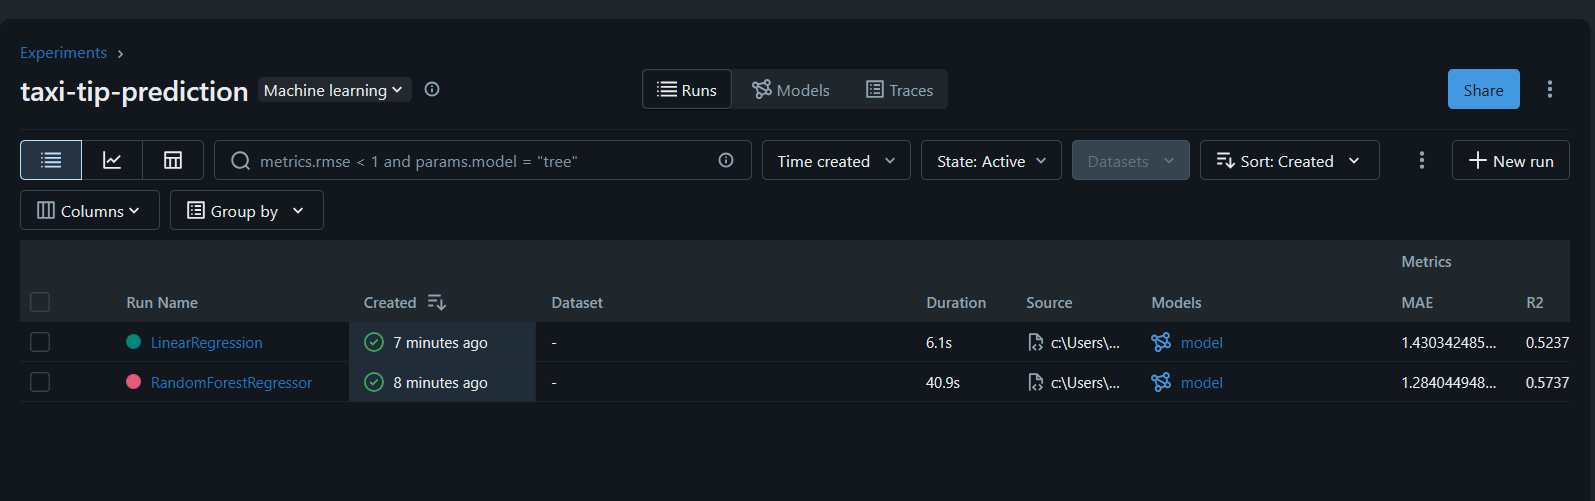
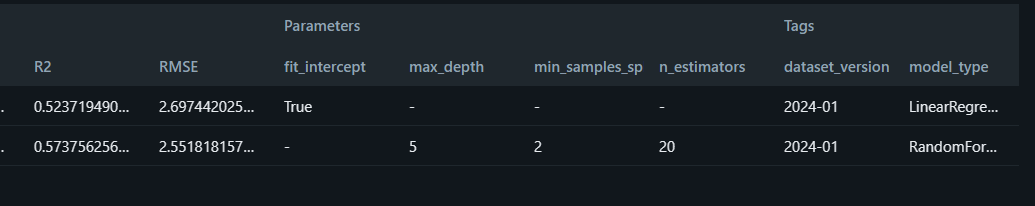

### Part 1.2

In [21]:
# Step 4: List and compare runs
import mlflow

# List all runs in the experiment
experiment = mlflow.get_experiment_by_name("taxi-tip-prediction")
runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

# Display runs side-by-side
runs[["run_id", "tags.model_type", "metrics.RMSE", "metrics.MAE", "metrics.R2"]]


,run_id,tags.model_type,metrics.RMSE,metrics.MAE,metrics.R2
0,0534fca82371449cbc0a15cae935c311,LinearRegression,2.697442,1.430342,0.523719
1,453987eddd254f26b641d9241d8f176f,RandomForestRegressor,2.551818,1.284045,0.573756


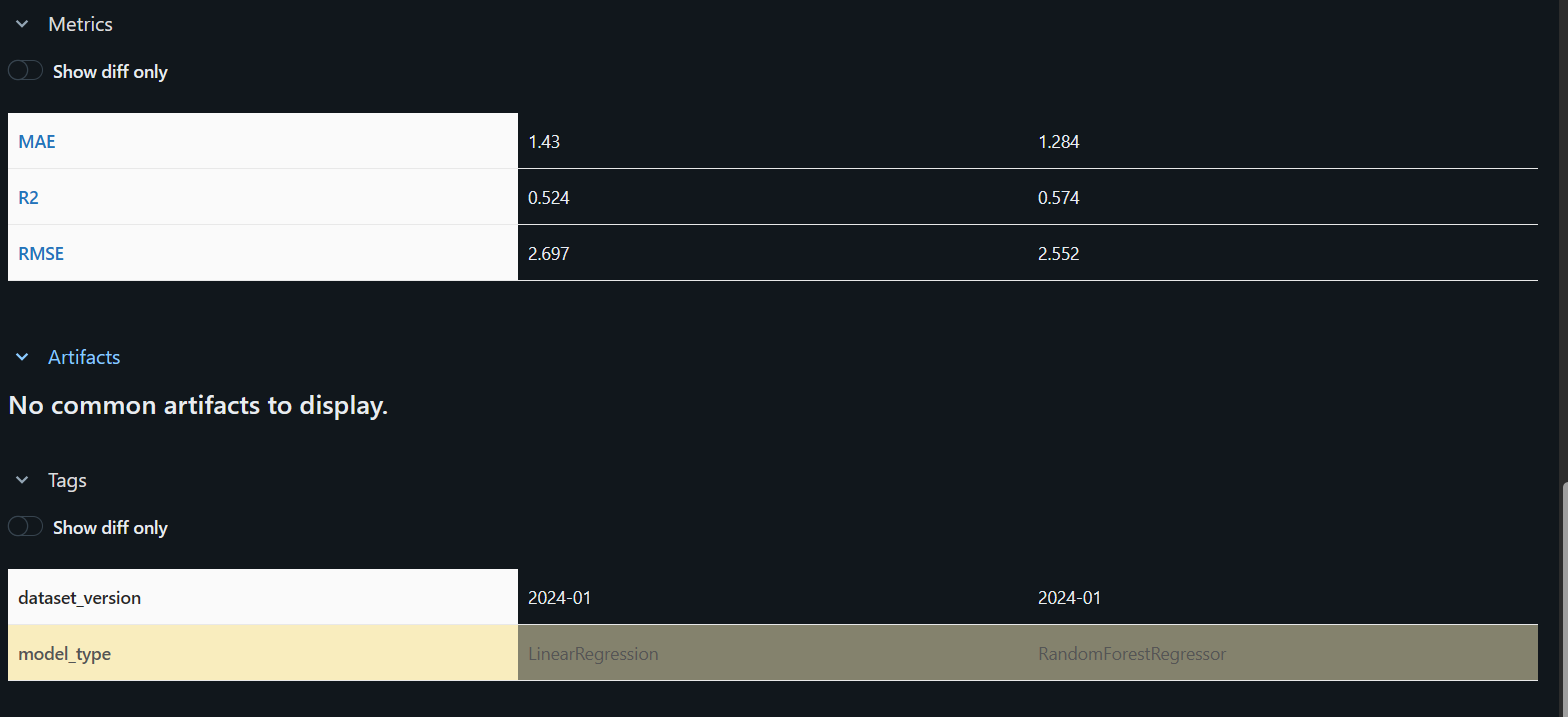

Explain here

In [23]:
#Step 5: Register best model in MLflow Model Registry
# Pick the best run (lowest RMSE)
best_run_id = runs.loc[runs['metrics.RMSE'].idxmin(), 'run_id']

model_uri = f"runs:/{best_run_id}/model"

# Register the model (no description here)
result = mlflow.register_model(
    model_uri=model_uri,
    name="taxi-tip-regressor"
)

print("Registered model:", result.name, "version:", result.version)



Successfully registered model 'taxi-tip-regressor'.
2026/04/14 03:59:48 WARNING mlflow.tracking._model_registry.fluent: Run with id 453987eddd254f26b641d9241d8f176f has no artifacts at artifact path 'model', registering model based on models:/m-3db070fbef074c74aebda62aaba47650 instead


Registered model: taxi-tip-regressor version: 1


Created version '1' of model 'taxi-tip-regressor'.


In [24]:
from mlflow import client

client = mlflow.tracking.MlflowClient()

# Update the version description
client.update_model_version(
    name="taxi-tip-regressor",
    version=result.version,
    description="Random Forest Regressor with RMSE=2.55, MAE=1.28, R²=0.57"
)


<ModelVersion: aliases=[], creation_timestamp=1776153588781, current_stage='None', deployment_job_state=None, description='Random Forest Regressor with RMSE=2.55, MAE=1.28, R²=0.57', last_updated_timestamp=1776153598260, metrics=[<Metric: dataset_digest=None, dataset_name=None, key='MAE', model_id='m-3db070fbef074c74aebda62aaba47650', run_id='453987eddd254f26b641d9241d8f176f', step=0, timestamp=1776152185332, value=1.2840449482495577>,
 <Metric: dataset_digest=None, dataset_name=None, key='R2', model_id='m-3db070fbef074c74aebda62aaba47650', run_id='453987eddd254f26b641d9241d8f176f', step=0, timestamp=1776152185332, value=0.5737562567586936>,
 <Metric: dataset_digest=None, dataset_name=None, key='RMSE', model_id='m-3db070fbef074c74aebda62aaba47650', run_id='453987eddd254f26b641d9241d8f176f', step=0, timestamp=1776152185332, value=2.551818157647236>], model_id='m-3db070fbef074c74aebda62aaba47650', name='taxi-tip-regressor', params={'max_depth': '5', 'min_samples_split': '2', 'n_estimator

In [ ]:
# Step 6: Load the registered model and make a sample prediction
from mlflow import pyfunc
import pandas as pd

# Load the registered model (version 1)
model = pyfunc.load_model("models:/taxi-tip-regressor/1")

# Use a row from your test set to guarantee schema match
# Replace X_test with the actual variable name you used for your test features
sample = X_test.iloc[[0]]   # take the first row

# Make a prediction
prediction = model.predict(sample)
print("Sample input:\n", sample)
print("\nSample prediction:", prediction)



Sample input:
          pickup_hour  pickup_day_of_week  trip_duration_minutes  \
1747886    -1.116293             0.06548               1.753636   

         trip_speed_mph  log_trip_distance  fare_per_mile  fare_per_minute  \
1747886        0.062057           2.729274       -0.05522        -0.030406   

         PU_Bronx  PU_Brooklyn  PU_EWR  ...  PU_Queens  PU_Staten Island  \
1747886     False        False   False  ...       True             False   

         PU_Unknown  DO_Bronx  DO_Brooklyn  DO_EWR  DO_Manhattan  DO_Queens  \
1747886       False     False        False   False          True      False   

         DO_Staten Island  DO_Unknown  
1747886             False       False  

[1 rows x 21 columns]

Sample prediction: [13.64042088]


## Part 2

Part 2.1

Check app.py

Part 2.2

Part 2.3

## Part 3

Part 3.1

Part 3.2